# Customer Churn Analysis

This project explores customer churn in a bank dataset.  
The goal is to understand **which factors influence churn** and provide insights that can help reduce customer attrition.

We will analyze:
- Overall churn distribution
- Demographic impact (gender, geography, age)
- Customer behavior (tenure, products, activity)
- Financial factors (credit score, balance, salary)
- Correlations between features and churn

### Import required libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## Data Loading & Overview

We start by loading the dataset and checking:
- Basic information (`info()`)
- Summary statistics (`describe()`)
- Missing values

This helps us understand the structure and quality of the data before analysis.

In [3]:
df = pd.read_csv('C:/Users/mishr/Desktop/CODE/Data Analysis/Customer-Churn-Analysis/Bank_Churn.csv')
print("Dataset loaded successfully!\n")

Dataset loaded successfully!



In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB
None
         CustomerId   CreditScore           Age        Tenure        Balance  \
count  1.000000e+04  10000.000000  10000.000000  100

In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [6]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

## Customer Churn Overview

First, we look at the overall churn distribution:
- **Bar chart**: Shows the count of customers who stayed vs churned.
- **Pie chart**: Shows the percentage split.

This gives us a quick sense of churn imbalance in the dataset.

C:\Users\mishr\AppData\Local\Temp\ipykernel_13696\2713116923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='Set2')


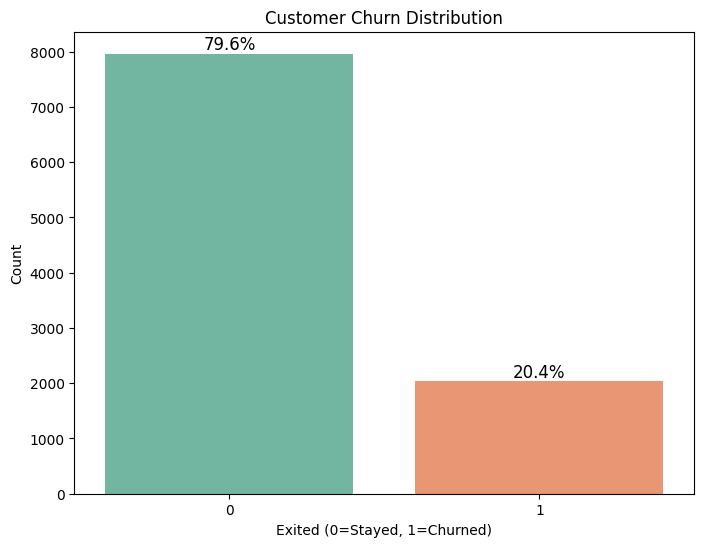

In [7]:
plt.figure(figsize=(8,6))
sns.countplot(x='Exited', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.ylabel('Count')

# Add percentage labels
total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    percentage = f'{100 * height/total:.1f}%'
    plt.gca().annotate(percentage, 
                       (p.get_x() + p.get_width()/2., height), 
                       ha='center', va='bottom', fontsize=12, color='black')
plt.show()

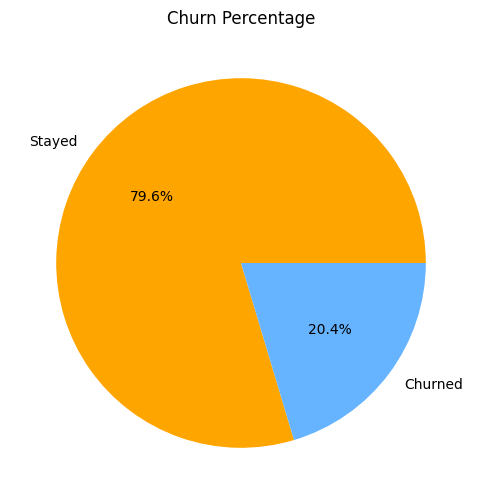

In [8]:
# Pie chart
churn_counts = df['Exited'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
        colors=['orange','#66b3ff'])
plt.title('Churn Percentage')
plt.show()

## Demographic Impact

We analyze how demographics affect churn:

- **Gender vs Churn**: Do male or female customers churn more?
- **Geography vs Churn**: Are customers from certain regions more likely to leave?
- **Age vs Churn**: Does age influence churn?  
  To make trends clearer, we group ages into buckets (18–30, 31–45, 46–60, 60+).

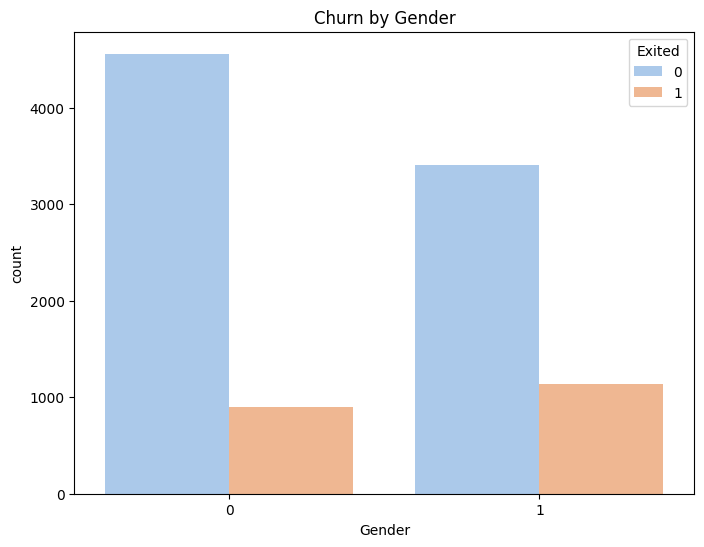

In [9]:
plt.figure(figsize=(8,6))
sns.countplot(x='Gender', hue='Exited', data=df, palette='pastel')
plt.title('Churn by Gender')
plt.show()

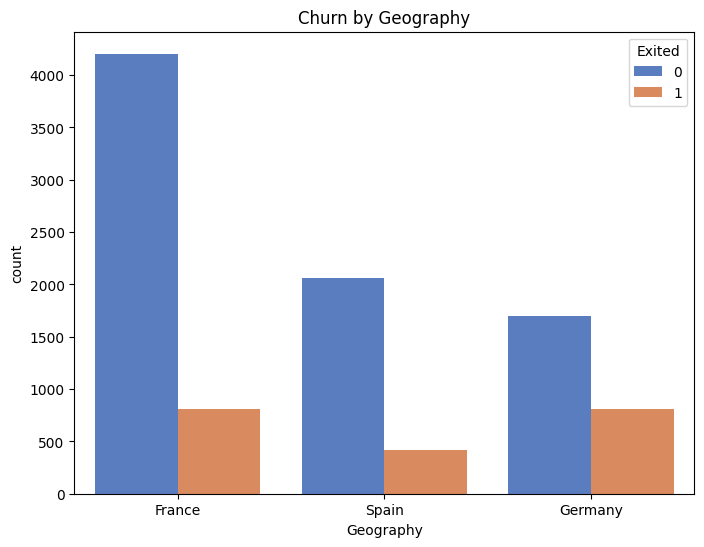

In [ ]:
df_plot = pd.read_csv("C:/Users/mishr/Desktop/CODE/Data Analysis/Customer-Churn-Analysis/Bank_Churn.csv")

plt.figure(figsize=(8,6))
sns.countplot(x='Geography', hue='Exited', data=df_plot, palette='muted')
plt.title('Churn by Geography')
plt.show()

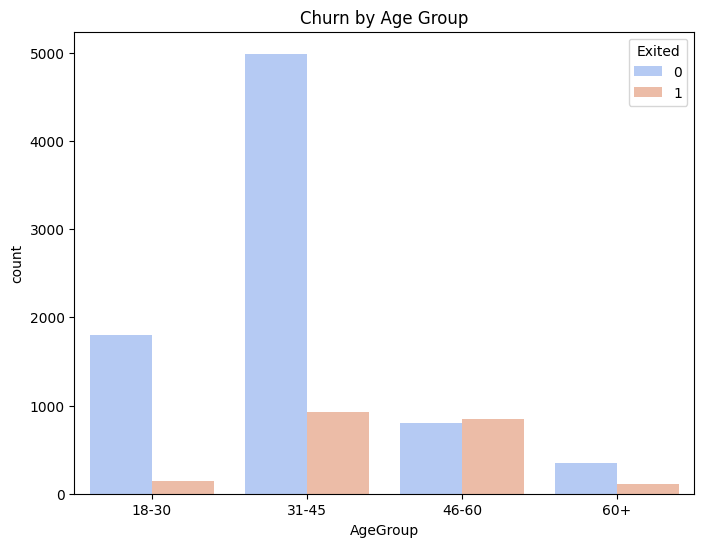

In [11]:
# Age buckets for clearer trends
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,45,60,100], labels=['18-30','31-45','46-60','60+'])
plt.figure(figsize=(8,6))
sns.countplot(x='AgeGroup', hue='Exited', data=df, palette='coolwarm')
plt.title('Churn by Age Group')
plt.show()

## Customer Behavior

We explore customer engagement and product usage:

- **Tenure vs Churn**: How long customers stay before leaving.
- **Products vs Churn**: Does the number of products affect churn?
- **Active Member vs Churn**: Are active members less likely to churn?

These behavioral factors often reveal loyalty patterns.

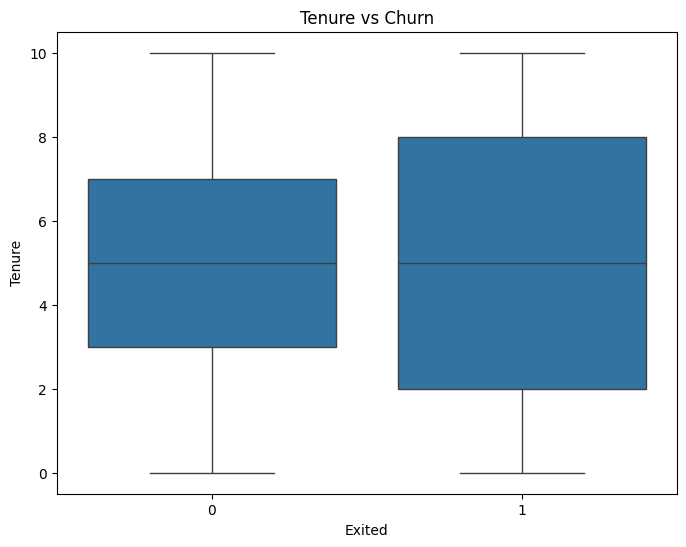

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Exited', y='Tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

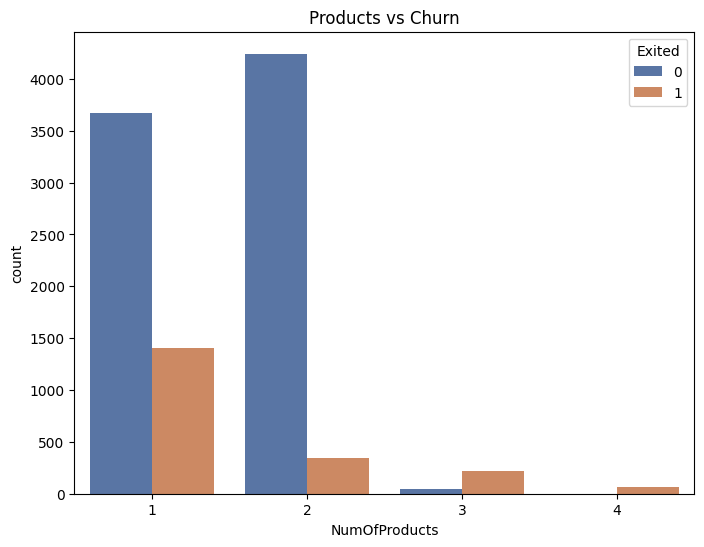

In [13]:
plt.figure(figsize=(8,6))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='deep')
plt.title('Products vs Churn')
plt.show()

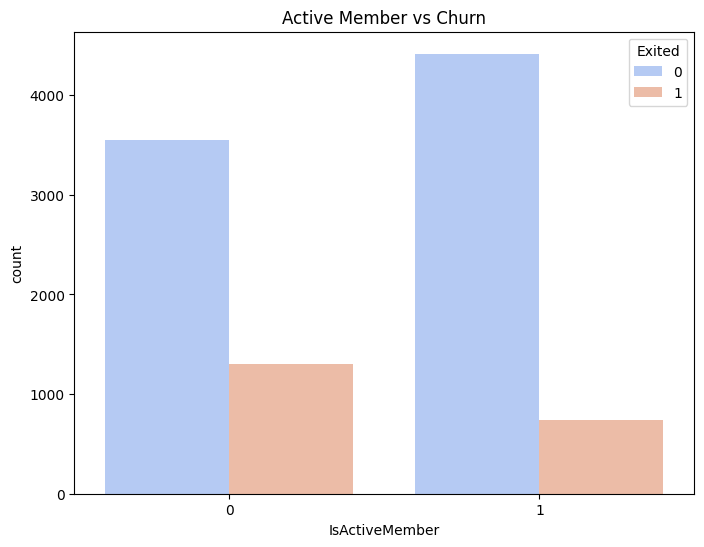

In [14]:
plt.figure(figsize=(8,6))
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='coolwarm')
plt.title('Active Member vs Churn')
plt.show()


## Financial Factors

We examine financial attributes:

- **Credit Score vs Churn**: Do customers with lower scores churn more?
- **Balance vs Churn**: Is account balance related to churn?
- **Estimated Salary vs Churn**: Does income level affect churn?

These features may indicate financial stability and engagement.

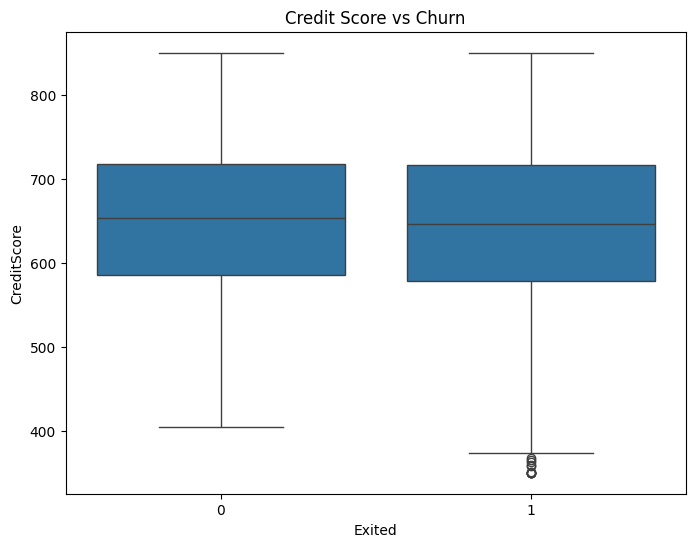

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Exited', y='CreditScore', data=df)
plt.title('Credit Score vs Churn')
plt.show()

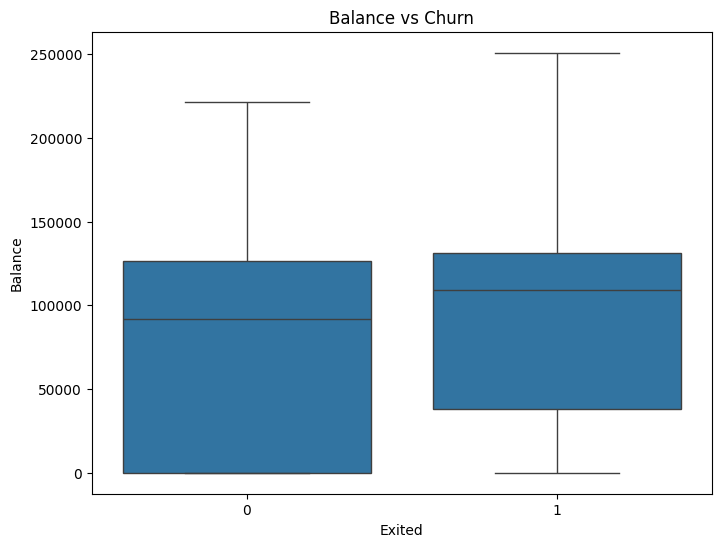

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance vs Churn')
plt.show()

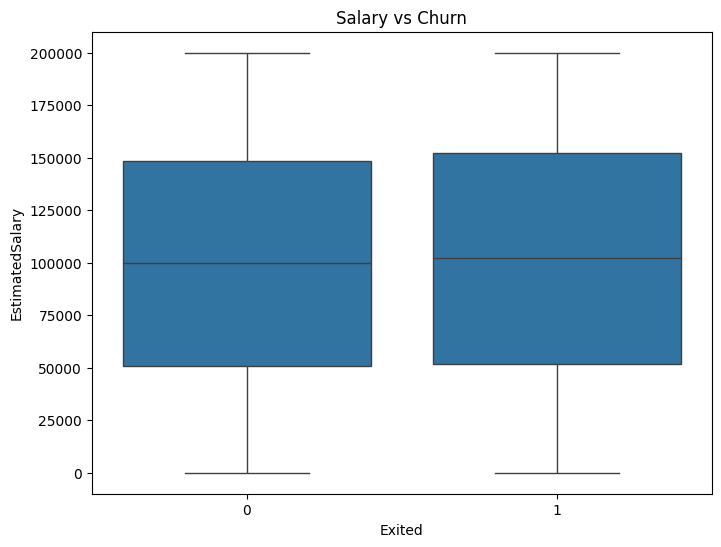

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Exited', y='EstimatedSalary', data=df)
plt.title('Salary vs Churn')
plt.show()

## Insights & Observations

From the analysis, we can summarize:

- Churn is imbalanced (majority stayed, minority churned).
- Age and geography show clear churn differences.
- Customers with fewer products or inactive memberships churn more.
- Financial factors like balance and credit score have moderate influence.
- Correlation analysis shows age has a stronger relationship with churn compared to salary or credit score.

These insights can guide **feature engineering** and **predictive modeling**.

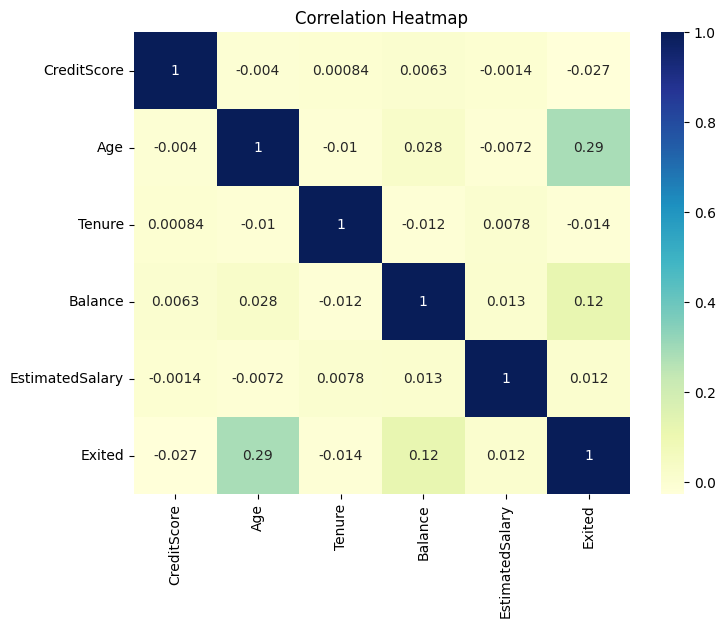

In [18]:
# Correlation Analysis
corr = df[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Exited']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# Pearson correlation examples
corr_val, _ = pearsonr(df['CreditScore'], df['Exited'])
print(f"Correlation between Credit Score and Churn: {corr_val:.2f}")

corr_val_age, _ = pearsonr(df['Age'], df['Exited'])
print(f"Correlation between Age and Churn: {corr_val_age:.2f}")

corr_val_tenure, _ = pearsonr(df['Tenure'], df['Exited'])
print(f"Correlation between Tenure and Churn: {corr_val_tenure:.2f}")

Correlation between Credit Score and Churn: -0.03
Correlation between Age and Churn: 0.29
Correlation between Tenure and Churn: -0.01


## Next Steps

To move beyond EDA, we can:

1. **Preprocess data**:
   - Encode categorical variables (Gender, Geography).
   - Scale numerical features.

2. **Model churn prediction**:
   - Logistic Regression, Random Forest, XGBoost.
   - Evaluate with ROC-AUC, precision, recall, and confusion matrix.

3. **Business recommendations**:
   - Target high-risk groups (older customers, inactive members).
   - Improve retention strategies in regions with higher churn.   